In [1]:
# Purpose: Import all libraries used for mesh handling, plotting, gravity simulation, inversion, and file export.
# This cell sets up the notebook-wide dependencies used in every later section.

from discretize import TreeMesh
from discretize.utils import active_from_xyz
import matplotlib.pyplot as plt
import numpy as np
import simpeg.potential_fields as pf
from simpeg import (
    data,
    data_misfit,
    directives,
    inverse_problem,
    inversion,
    maps,
    optimization,
    regularization,
    utils,
)
from simpeg.utils import io_utils, plot2Ddata

# Common Python functionality
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import os

## Setup

## 1. import mesh and model

In [2]:
# Purpose: Load the octree mesh that defines the computational domain for forward modelling and inversion.

# Load mesh from local directory
mesh_file = "mesh_tutorial.ubc"
mesh = TreeMesh.read_UBC(mesh_file)

In [3]:
# Purpose: Load the true synthetic geology model defined on the mesh cells.

# Load true geology model from local directory
true_geology_file = "geology_true.mod"
true_geology = mesh.read_model_UBC(true_geology_file)

## 2. plot mesh and model

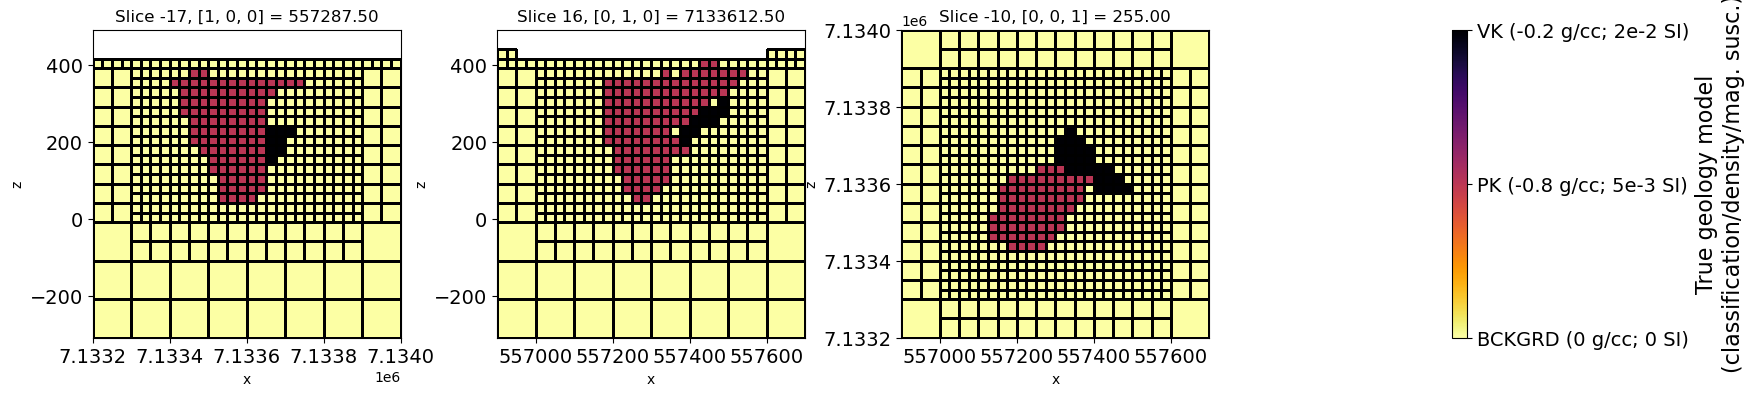

In [4]:
# Purpose: Plot several 2D slices of the true geology model to inspect the subsurface classes before inversion.

# Plot true geology model
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ticksize, labelsize = 14, 16
for _, axx in enumerate(ax):
    axx.set_aspect(1)
    axx.tick_params(labelsize=ticksize)
mesh.plot_slice(
    true_geology,
    normal="X",
    ax=ax[0],
    ind=-17,
    clim=[0, 2],
    pcolor_opts={"cmap": "inferno_r"},
    grid=True,
)
mesh.plot_slice(
    true_geology,
    normal="Y",
    ax=ax[1],
    clim=[0, 2],
    pcolor_opts={"cmap": "inferno_r"},
    grid=True,
)
geoplot = mesh.plot_slice(
    true_geology,
    normal="Z",
    ax=ax[2],
    clim=[0, 2],
    ind=-10,
    pcolor_opts={"cmap": "inferno_r"},
    grid=True,
)
geocb = plt.colorbar(geoplot[0], cax=ax[3], ticks=[0, 1, 2])
geocb.set_label(
    "True geology model\n(classification/density/mag. susc.)", fontsize=labelsize
)
geocb.set_ticklabels(
    ["BCKGRD (0 g/cc; 0 SI)", "PK (-0.8 g/cc; 5e-3 SI)", "VK (-0.2 g/cc; 2e-2 SI)"]
)
geocb.ax.tick_params(labelsize=ticksize)
ax[3].set_aspect(10)
plt.show()


C:\Users\30562\AppData\Local\Temp\ipykernel_44048\386433864.py:57: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  p.show()


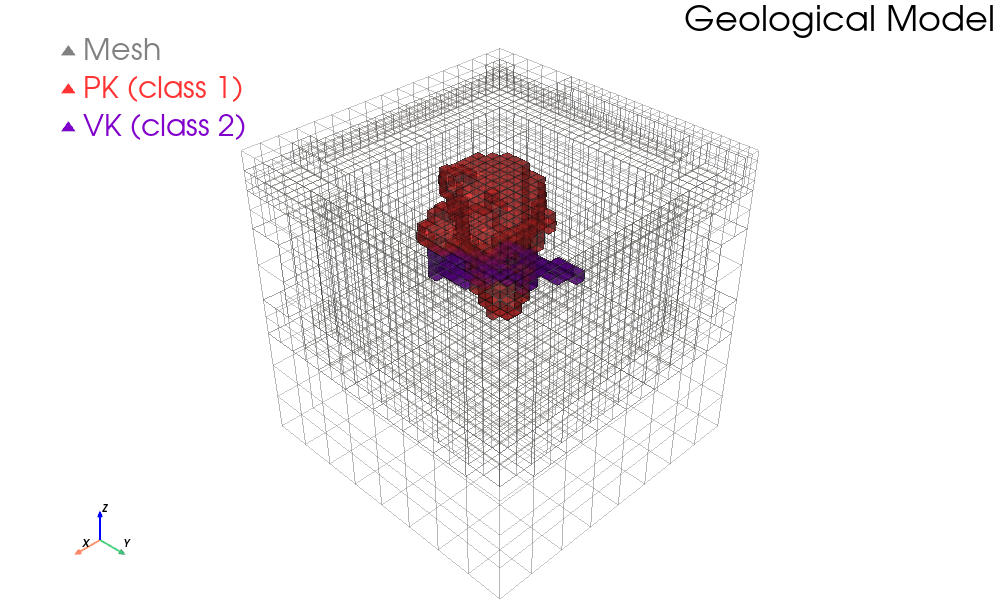

In [5]:
# Purpose: Build an interactive 3D view of the geological model and highlight the ore-body cells.

# 3D visualization - mesh wireframe and discrete colors (PyVista)
import pyvista as pv

# Extract only ore-body cells (class 1: PK, class 2: VK; exclude background class 0)
mask_orebody = (true_geology > 0)  # True for ore bodies
cell_ids = np.where(mask_orebody)[0]

# Convert the mesh to an UnstructuredGrid
ug = mesh.to_vtk()  # Convert TreeMesh to VTK

# Extract ore-body cells and their class values
ug_orebody = ug.extract_cells(cell_ids)
geology_orebody = true_geology[cell_ids]

# Attach geology class data to the extracted grid
ug_orebody["geology"] = geology_orebody

# Discrete color mapping (PK=1: red, VK=2: purple)
geology_colors = {
    1: [1.0, 0.2, 0.2],  # PK - red
    2: [0.5, 0.0, 0.8],  # VK - purple
}

p = pv.Plotter(window_size=(1000, 600))
p.background_color = "white"  # White background

# Add the full mesh wireframe as a reference frame (semi-transparent gray)
p.add_mesh(
    ug,
    style="wireframe",
    color="gray",
    line_width=0.1,
    opacity=0.2,
    label="Mesh",
)

# Add separate mesh overlays for the two ore bodies
for ore_class, color in geology_colors.items():
    mask = geology_orebody == ore_class
    cell_subset = ug_orebody.extract_cells(np.where(mask)[0])
    label = f"PK (class {ore_class})" if ore_class == 1 else f"VK (class {ore_class})"
    p.add_mesh(
        cell_subset,
        color=color,
        show_edges=True,
        edge_color="black",
        line_width=0.5,
        opacity=0.7,
        label=label,
    )

p.add_axes(line_width=2)
p.add_legend(loc="upper left")
p.add_text("Geological Model", position="upper_right", font_size=14)
p.show()

In [6]:
# Purpose: Export VTK files so the mesh and ore bodies can be inspected in ParaView or another external viewer.

# Export VTK files

# Create the output directory
output_dir = "vtk_output"
os.makedirs(output_dir, exist_ok=True)

# Export the full mesh with geology classes
mesh_file_path = os.path.join(output_dir, "geological_mesh_full.vtk")
ug.save(mesh_file_path)
print(f"âœ“ Full mesh saved: {mesh_file_path}")

# Export the ore-body mesh only
orebody_file_path = os.path.join(output_dir, "ore_bodies.vtk")
ug_orebody.save(orebody_file_path)
print(f"âœ“ Ore-body mesh saved: {orebody_file_path}")

print(f"\nAll files were saved in: {os.path.abspath(output_dir)}")
print(f"These files can be opened with ParaView or another VTK viewer")

âœ“ Full mesh saved: vtk_output\geological_mesh_full.vtk
âœ“ Ore-body mesh saved: vtk_output\ore_bodies.vtk

All files were saved in: c:\Users\30562\OneDrive\Desktop\UBC\Y4\EOSC454\Project\eosc-454-project-2026\gravity\Geological_model_Inversion\vtk_output
These files can be opened with ParaView or another VTK viewer


## 3. import gravity data

In [7]:
# Purpose: Load the gravity observation file used as input to the inversion workflow.

# Load gravity data from local directory
data_grav_file = "gravity_data.obs"
data_grav = io_utils.read_grav3d_ubc(data_grav_file)

C:\Users\30562\AppData\Local\Temp\ipykernel_44048\1162460228.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


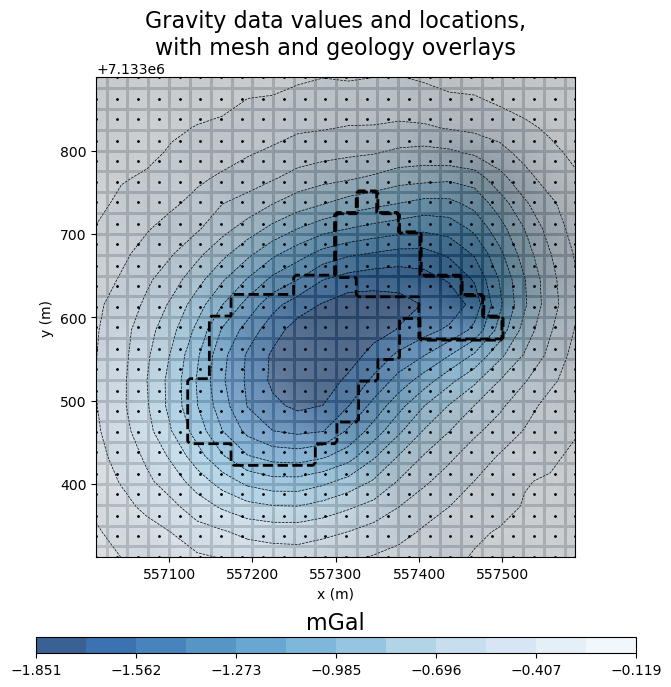

In [8]:
# Purpose: Plot the gravity observations in map view together with the mesh footprint for spatial context.

# plot gravity data and mesh
fig = plt.figure(figsize=(10, 8))

# main axis
ax = fig.add_axes([0.1, 0.2, 0.8, 0.6])

mesh.plot_slice(
    np.ones(mesh.nC),
    normal="Z",
    ind=int(-10),
    grid=True,
    pcolor_opts={"cmap": "Greys"},
    ax=ax,
)

mm = utils.plot2Ddata(
    data_grav.survey.receiver_locations,
    -data_grav.dobs,
    ax=ax,
    level=True,
    nx=20,
    ny=20,
    dataloc=True,
    ncontour=12,
    shade=True,
    contourOpts={"cmap": "Blues_r", "alpha": 0.8},
    levelOpts={"colors": "k", "linewidths": 0.5, "linestyles": "dashed"},
)

ax.set_aspect(1)
ax.set_title(
    "Gravity data values and locations,\nwith mesh and geology overlays",
    fontsize=16,
)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

ax.set_xlim(
    [
        data_grav.survey.receiver_locations[:, 0].min(),
        data_grav.survey.receiver_locations[:, 0].max(),
    ],
)
ax.set_ylim(
    [
        data_grav.survey.receiver_locations[:, 1].min(),
        data_grav.survey.receiver_locations[:, 1].max(),
    ],
)

# overlay true geology model for comparison
indz = -10
indslicezplot = mesh.gridCC[:, 2] == mesh.cell_centers_z[indz]

utils.plot2Ddata(
    mesh.gridCC[indslicezplot][:, [0, 1]],
    true_geology[indslicezplot],
    nx=200,
    ny=200,
    contourOpts={"alpha": 0},
    clim=[0, 2],
    ax=ax,
    level=True,
    ncontour=2,
    levelOpts={"colors": "k", "linewidths": 2, "linestyles": "--"},
    method="nearest",
)

# colorbar axis
cax = fig.add_axes([0.2, 0.08, 0.6, 0.02])
plt.colorbar(mm[0], cax=cax, orientation="horizontal")
cax.set_title("mGal", fontsize=16)

plt.tight_layout()
plt.show()

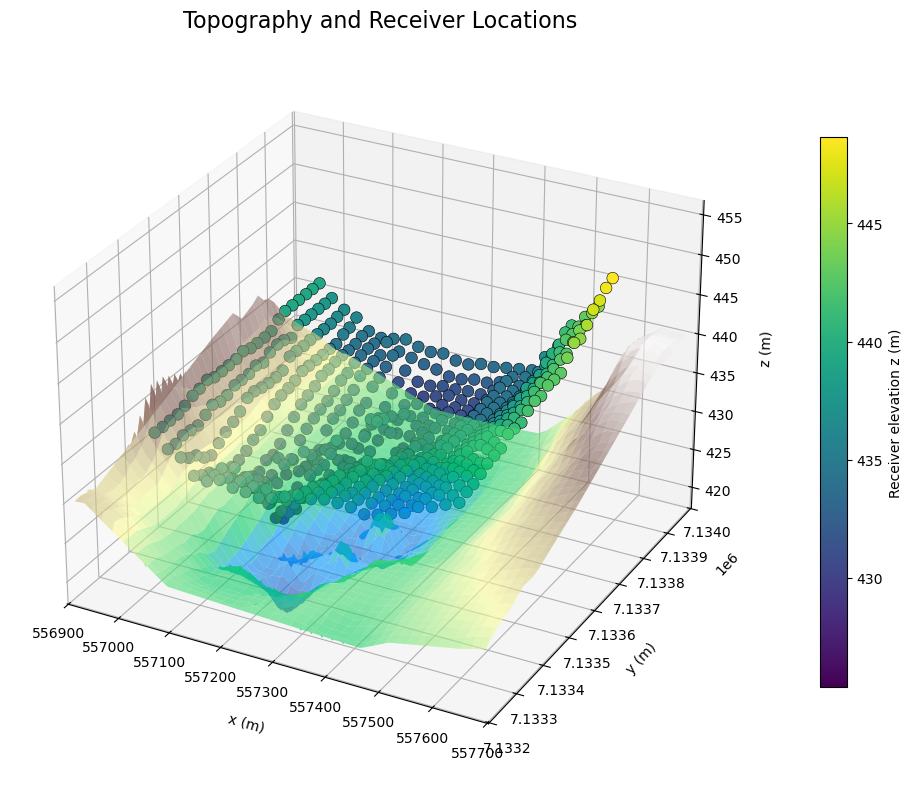

In [9]:
# Purpose: Show a local 3D view of topography and receiver locations to verify survey geometry near the target area.

# Zoomed-in 3D view: topography + receiver locations
rx = data_grav.survey.receiver_locations

# Ensure topography is available even when cells are run out of order
if "topo" not in globals():
    topo_file = "CDED_Lake_warp.xyz"
    topo = np.genfromtxt(topo_file, skip_header=1)

# Receiver bounds with padding
x_min, x_max = rx[:, 0].min(), rx[:, 0].max()
y_min, y_max = rx[:, 1].min(), rx[:, 1].max()
z_min, z_max = rx[:, 2].min(), rx[:, 2].max()

x_pad = 0.20 * (x_max - x_min)
y_pad = 0.20 * (y_max - y_min)
z_pad = max(5.0, 0.35 * (z_max - z_min))

x_lim = (x_min - x_pad, x_max + x_pad)
y_lim = (y_min - y_pad, y_max + y_pad)
z_lim = (z_min - z_pad, z_max + z_pad)

# Keep only local topography around receivers
topo_mask = (
    (topo[:, 0] >= x_lim[0]) & (topo[:, 0] <= x_lim[1]) &
    (topo[:, 1] >= y_lim[0]) & (topo[:, 1] <= y_lim[1])
)
topo_local = topo[topo_mask]

# Fallback in case local selection is too small
if topo_local.shape[0] < 20:
    topo_local = topo

# Interpolate local topography onto a regular grid
x_topo, y_topo, z_topo = topo_local[:, 0], topo_local[:, 1], topo_local[:, 2]
xi = np.linspace(x_topo.min(), x_topo.max(), 120)
yi = np.linspace(y_topo.min(), y_topo.max(), 120)
XI, YI = np.meshgrid(xi, yi)
interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
ZI = interp(XI, YI)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Local topography surface
ax.plot_surface(
    XI, YI, ZI,
    cmap="terrain",
    linewidth=0,
    antialiased=True,
    alpha=0.60,
    shade=True,
    vmin=np.nanmin(ZI),
    vmax=np.nanmax(ZI),
)

# Receivers (larger markers for visibility)
sc = ax.scatter(
    rx[:, 0], rx[:, 1], rx[:, 2],
    s=70,
    c=rx[:, 2],
    cmap="viridis",
    edgecolors="k",
    linewidths=0.4,
    depthshade=False,
    zorder=5,
    label="Receivers",
)

ax.set_xlim(x_lim)
ax.set_ylim(y_lim)
ax.set_zlim(z_lim)
ax.set_xlabel("x (m)", labelpad=10)
ax.set_ylabel("y (m)", labelpad=10)
ax.set_zlabel("z (m)", labelpad=10)
ax.view_init(elev=28, azim=-62)

cbar = plt.colorbar(sc, ax=ax, pad=0.08, shrink=0.75)
cbar.set_label("Receiver elevation z (m)")

# Figure-level title stays centered even with colorbar
fig.suptitle("Topography and Receiver Locations", x=0.4, y=0.98, fontsize=16)

plt.tight_layout()
plt.show()

## 4. import topography

In [10]:
# Purpose: Load the topography points used to define the surface and active subsurface cells.

# Load Topo from local directory
topo_file = "CDED_Lake_warp.xyz"
topo = np.genfromtxt(topo_file, skip_header=1)

In [11]:
# Purpose: Identify active cells below topography and define mappings used for inversion and plotting.

# find the active cells
active_cells = active_from_xyz(mesh, topo, "CC")

# Create active map to go from reduced set to full
plotting_Map = maps.InjectActiveCells(mesh, active_cells, np.nan)
n_active = int(active_cells.sum())

# Identity map for density-only inversion
model_Map = maps.IdentityMap(nP=n_active)

## 5. Inversion

## a. Baseline WLS Inversion

In [68]:
# Purpose: Define the starting model and reference model for the baseline L2 inversion.

# Starting/Reference Models
starting_model = 1e-6 * np.ones(n_active)
reference_model = np.zeros_like(starting_model)

# Helper function for plotting Tikhonov curves from the saved inversion history
def plot_tikhonov_curve(save_output_directive, title, ax=None):
    beta = np.asarray(save_output_directive.beta, dtype=float)
    phi_d = np.asarray(save_output_directive.phi_d, dtype=float)
    phi_m = np.asarray(save_output_directive.phi_m, dtype=float)

    if len(beta) == 0:
        if ax is not None:
            ax.axis("off")
            ax.text(0.5, 0.5, f"No history for\n{title}", ha="center", va="center")
            return
        print(f"No inversion history recorded for {title}.")
        return

    try:
        target_misfit = np.sum(
            [dmis.nD for dmis in save_output_directive.invProb.dmisfit.objfcts]
        )
    except AttributeError:
        target_misfit = save_output_directive.invProb.dmisfit.simulation.survey.nD

    # Use the actual beta that produced the final recovered model.
    i_used = len(beta) - 1

    if ax is not None:
        ax.plot(phi_m, phi_d, "o-k", lw=1.5, ms=4)
        ax.axhline(target_misfit, color="k", linestyle="--", lw=1.2)
        ax.plot(phi_m[i_used], phi_d[i_used], "r*", ms=10)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("phi_m")
        ax.set_ylabel("phi_d")
        ax.set_title(title)
        return

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

    ax1.plot(beta, phi_d, "o-k", lw=1.5, ms=4)
    ax1.axhline(target_misfit, color="k", linestyle="--", lw=1.2)
    ax1.plot(beta[i_used], phi_d[i_used], "r*", ms=10)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel("Beta")
    ax1.set_ylabel("Data misfit (phi_d)")
    ax1.set_title("Data Misfit vs Beta")

    ax2.plot(beta, phi_m, "o-r", lw=1.5, ms=4)
    ax2.plot(beta[i_used], phi_m[i_used], "r*", ms=10)
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel("Beta")
    ax2.set_ylabel("phi_m")
    ax2.set_title("Model Objective vs Beta")

    ax3.plot(phi_m, phi_d, "o-k", lw=1.5, ms=4)
    ax3.axhline(target_misfit, color="k", linestyle="--", lw=1.2)
    ax3.plot(phi_m[i_used], phi_d[i_used], "r*", ms=10)
    ax3.set_xscale("log")
    ax3.set_yscale("log")
    ax3.set_xlabel("phi_m")
    ax3.set_ylabel("phi_d")
    ax3.set_title("Tikhonov Trade-off Curve")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

In [13]:
# Purpose: Set up the gravity forward simulation, L2 data misfit, regularization, optimizer, and inversion directives.

# Simulation
simulation_grav = pf.gravity.simulation.Simulation3DIntegral(
    survey=data_grav.survey,
    mesh=mesh,
    rhoMap=model_Map,
    active_cells=active_cells,
    engine="choclo",
)

# Data misfit
dmis_L2 = data_misfit.L2DataMisfit(data=data_grav, simulation=simulation_grav)


# Regularization
reg_L2 = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    length_scale_x=1.0, # Smoothness in the x direction; use different directional scales if geological prior information supports anisotropy.
    length_scale_y=1.0,
    length_scale_z=1.0,
    reference_model=reference_model, # zero reference model
    reference_model_in_smooth=False, # Use the reference model only in the smallness term, not in the smoothness terms.
)


# Optimizaiton
opt_L2 = optimization.InexactGaussNewton(
    maxIter=100, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)


# Directives
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_output_l2 = directives.SaveOutputEveryIteration(save_txt=False)

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_output_l2,
]

c:\Users\30562\anaconda3\envs\simpeg_env\Lib\site-packages\simpeg\directives\_directives.py:1865: FutureWarning: SaveEveryIteration.save_txt has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  self.save_txt = save_txt
c:\Users\30562\anaconda3\envs\simpeg_env\Lib\site-packages\simpeg\directives\_directives.py:1866: FutureWarning: SaveEveryIteration.save_txt has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  on_disk = self.save_txt


Define and Run the Inversion

In [14]:
# Purpose: Assemble the baseline inverse problem and run the weighted least-squares inversion.

# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run inversion
recovered_model = inv_L2.run(starting_model)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 576.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.09e+00  4.35e+06  4.67e-04  4.35e+06                                 
   1  1.09e+00  5.46e+05  8.18e+05  1.44e+06    1.61e+06      0              
   2  5.47e-01  2.40e+05  1.21e+06  9.00e+05    2.18e+05      0              
   3  2.73e-01  9.39e+04  1.57e+06  5.25e+05    1.26e+05      0              
   4  1.37e-01  3.34e+04  1.88e+06  2.90e+05    6.81e+04      0              
   5  6.84e-02  1.14e+04  2.10e+06  1.55e+05    3.57e+04      0              
   6  3.42e-02  3.99e+03  2.24e+06  8.06e+04    1.84e+04      0              
   7  1.71e-02  1.61e+03  2.34e+06  4.15e+04    9.36e+03      0              
   8  8.55e-03  8.28e+02  2.40e+06  2.13e+04    4.87e+03      0              
   9  4.27e-03  5.31e+02  2.45e+06  1.10e+04    2.51e+03      0

In [15]:
# Purpose: Store the predicted data and key survey arrays from the baseline inversion for later comparison plots.

# Predicted data with final recovered model.
dpred = inv_prob_L2.dpred

# Data
dobs = data_grav.dobs
receiver_locations = data_grav.survey.receiver_locations

Plot result

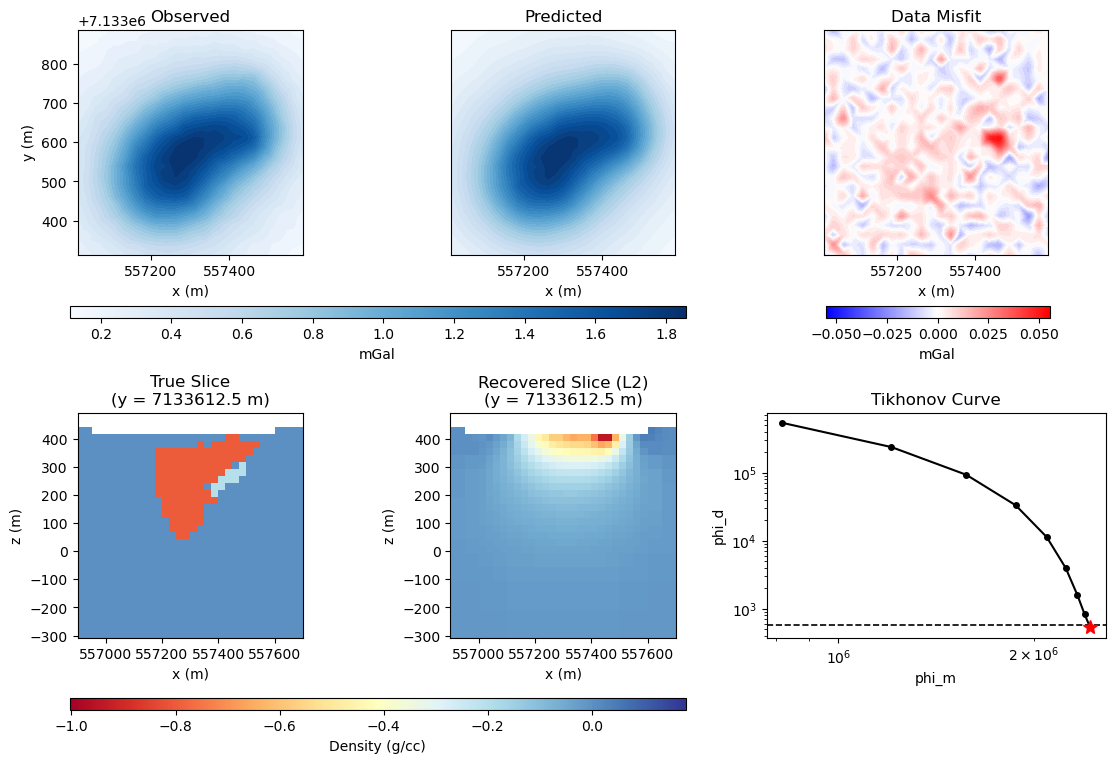

In [78]:
# Purpose: Visualize observed data, predicted data, residuals, and a representative recovered density slice for the baseline L2 case.

# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
data_array_l2 = np.c_[dobs, dpred, dobs - dpred]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

norm_data = mpl.colors.Normalize(
    vmin=np.min(data_array_l2[:, :2]),
    vmax=np.max(data_array_l2[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(data_array_l2[:, 2])),
    vmax=np.max(np.abs(data_array_l2[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_l2[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_l2[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_l2[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_tikhonov = fig.add_subplot(gs[1, 2])

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Fix model color scale across all inversion cases when available
shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_reweighted_l2_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (L2)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

fig.subplots_adjust(bottom=0.12)
# Small model colorbar (below lower-row panels 1 and 2)
cax_model = fig.add_axes([0.16, 0.03, 0.44, 0.015])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="horizontal")
cbar_model.set_label("Density (g/cc)")

plot_tikhonov_curve(save_output_l2, "Tikhonov Curve", ax=ax_tikhonov)

plt.show()

## b. Reweighted-data L2
Use reweighted uncertainties while keeping the same L2 inversion framework for fair comparison of reweighting effects.

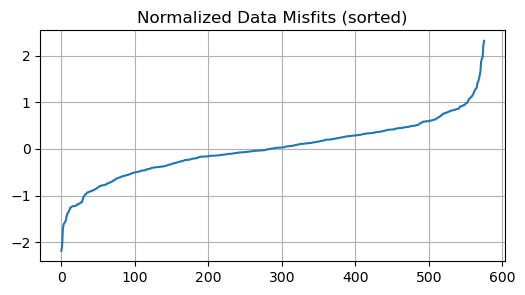

In [17]:
# Purpose: Reweight the data uncertainties using the baseline residuals so misfit-heavy points receive more influence.

# Build reweighted data object from baseline L2 residuals
max_anomaly = np.max(np.abs(dobs))
floor = 0.005 * max_anomaly
percent = 0.01
uncertainties = percent * np.abs(dobs) + floor

normalized_data_misfits = (dobs - dpred) / uncertainties

new_uncertainties = uncertainties.copy()
uncertainty_reduce_factor = 2.5
new_uncertainties[np.abs(normalized_data_misfits) > 1] /= uncertainty_reduce_factor

new_data_object = data.Data(
    survey=data_grav.survey,
    dobs=dobs,
    standard_deviation=new_uncertainties,
)

fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111)
ax.plot(np.sort(normalized_data_misfits))
ax.set_title("Normalized Data Misfits (sorted)")
ax.grid()
plt.show(fig)

In [18]:
# Purpose: Run a second L2 inversion using the reweighted uncertainties while keeping the same inversion framework.

# Reweighted-data L2 inversion (same L2 framework, new data uncertainties only)
dmis_l2_reweighted = data_misfit.L2DataMisfit(
    data=new_data_object,
    simulation=simulation_grav,
)

reg_l2_reweighted = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    length_scale_x=1.0,
    length_scale_y=1.0,
    length_scale_z=1.0,
    reference_model=reference_model,
    reference_model_in_smooth=False,
)

opt_l2_reweighted = optimization.InexactGaussNewton(
    maxIter=100, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

inv_prob_l2_reweighted = inverse_problem.BaseInvProblem(
    dmis_l2_reweighted, reg_l2_reweighted, opt_l2_reweighted
)

update_jacobi_l2_reweighted = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta_l2_reweighted = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule_l2_reweighted = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit_l2_reweighted = directives.TargetMisfit(chifact=1.0)
save_output_l2_reweighted = directives.SaveOutputEveryIteration(save_txt=False)

directives_list_l2_reweighted = [
    update_jacobi_l2_reweighted,
    starting_beta_l2_reweighted,
    beta_schedule_l2_reweighted,
    target_misfit_l2_reweighted,
    save_output_l2_reweighted,
]

inv_l2_reweighted = inversion.BaseInversion(
    inv_prob_l2_reweighted, directives_list_l2_reweighted
)
recovered_reweighted_l2_model = inv_l2_reweighted.run(starting_model)

c:\Users\30562\anaconda3\envs\simpeg_env\Lib\site-packages\simpeg\directives\_directives.py:1865: FutureWarning: SaveEveryIteration.save_txt has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  self.save_txt = save_txt
c:\Users\30562\anaconda3\envs\simpeg_env\Lib\site-packages\simpeg\directives\_directives.py:1866: FutureWarning: SaveEveryIteration.save_txt has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  on_disk = self.save_txt
INFO: Directive TargetMisfit: Target data misfit is 576.0



Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  7.74e-01  1.38e+06  4.67e-04  1.38e+06                                 
   1  7.74e-01  3.25e+05  3.67e+05  6.10e+05    7.25e+05      0              
   2  3.87e-01  1.85e+05  6.24e+05  4.26e+05    1.15e+05      0              
   3  1.93e-01  9.39e+04  9.54e+05  2.78e+05    7.03e+04      0              
   4  9.67e-02  4.18e+04  1.33e+06  1.70e+05    4.03e+04      0              
   5  4.84e-02  1.65e+04  1.69e+06  9.81e+04    2.23e+04      0              
   6  2.42e-02  6.07e+03  1.98e+06  5.40e+04    1.20e+04      0              
   7  1.21e-02  2.26e+03  2.20e+06  2.88e+04    6.38e+03      0              
   8  6.04e-03  9.61e+02  2.34e+06  1.51e+04    3.30e+03      0              
   9  3.02e-03  4.98e+02

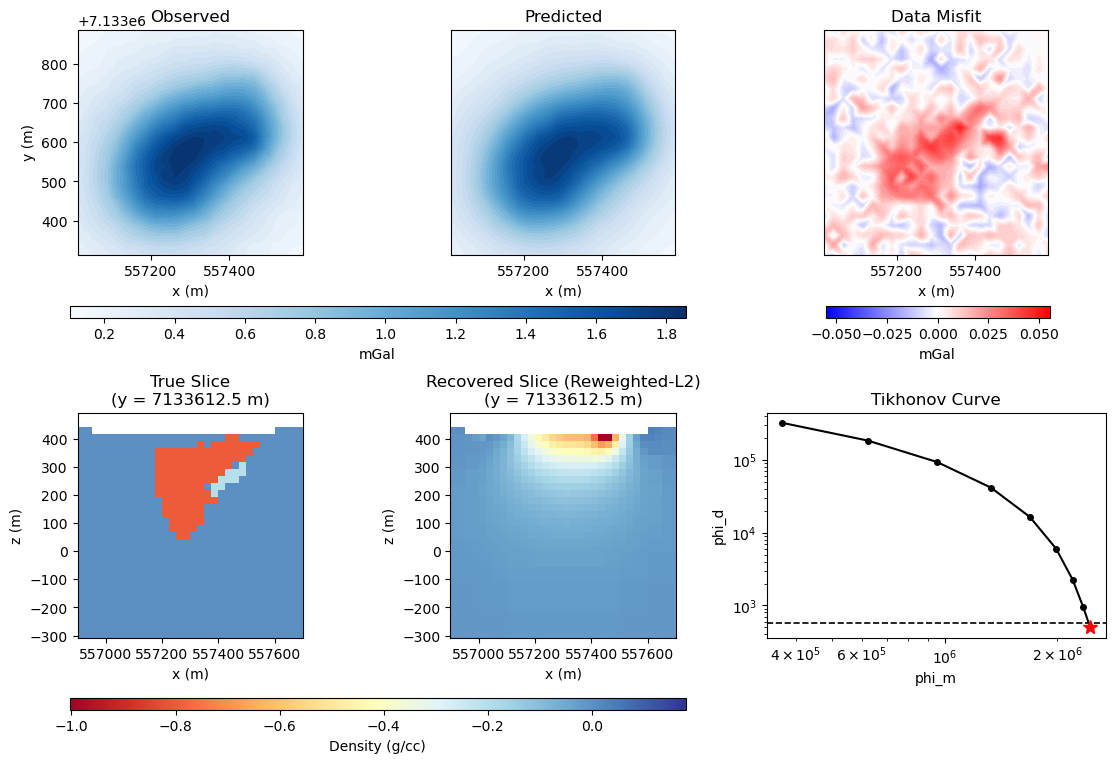

In [73]:
# Purpose: Visualize the reweighted-data L2 results and compare them against the baseline observations and truth.

# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
dpred_l2_reweighted = inv_prob_l2_reweighted.dpred
data_array_l2_reweighted = np.c_[dobs, dpred_l2_reweighted, dobs - dpred_l2_reweighted]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

# Use a shared data/misfit color scale across all cases when available
shared_data_arrays = [data_array_l2_reweighted]
for name in ["data_array_l2", "data_array_irls", "data_array_depth", "data_array_sens"]:
    if name in globals():
        shared_data_arrays.append(globals()[name])
all_data_arrays = np.vstack(shared_data_arrays)

norm_data = mpl.colors.Normalize(
    vmin=np.min(all_data_arrays[:, :2]),
    vmax=np.max(all_data_arrays[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(all_data_arrays[:, 2])),
    vmax=np.max(np.abs(all_data_arrays[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_l2_reweighted[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_l2_reweighted[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_l2_reweighted[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_tikhonov = fig.add_subplot(gs[1, 2])

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_reweighted_l2_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_reweighted_l2_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (Reweighted-L2)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

fig.subplots_adjust(bottom=0.12)
# Small model colorbar (below lower-row panels 1 and 2)
cax_model = fig.add_axes([0.16, 0.03, 0.44, 0.015])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="horizontal")
cbar_model.set_label("Density (g/cc)")

plot_tikhonov_curve(save_output_l2_reweighted, "Tikhonov Curve", ax=ax_tikhonov)

plt.show()

## c. IRLS Baseline (Sparse-norm, original data_grav)

Sparse-norm regularization

In [20]:
# Purpose: Define the sparse IRLS data misfit and regularization for the baseline sparse inversion experiment.

# Data misfit for IRLS baseline (using original data_grav, not reweighted)
dmis_irls = data_misfit.L2DataMisfit(data=data_grav, simulation=simulation_grav)

# Regularization for IRLS
dh = min(mesh.h[0].min(), mesh.h[1].min(), mesh.h[2].min())
print(dh)

reg_irls = regularization.Sparse(
    mesh,
    active_cells=active_cells,
    alpha_s=dh**-2,
    alpha_x=1,
    alpha_y=1,
    alpha_z=1,
    reference_model=reference_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

25.0


In [21]:
# Purpose: Define the optimizer and directives that control the IRLS update schedule and convergence behaviour.

# Optimization for IRLS
opt_irls = optimization.ProjectedGNCG(
    maxIter=100, lower=-1.0, upper=1.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

# Directives for IRLS
starting_beta_irls = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls = directives.UpdateIRLS(
    cooling_factor=2,
    cooling_rate=1,
    chifact_start=1.0,
    f_min_change=1e-4,
    max_irls_iterations=25,
)
save_output_irls = directives.SaveOutputEveryIteration(save_txt=False)

directives_list_irls = [
    update_irls,
    starting_beta_irls,
    update_jacobi_irls,
    save_output_irls,
]

Define and Run the Inversion

In [22]:
# Purpose: Assemble and run the baseline sparse IRLS inversion.

# Inverse problem for IRLS
inv_prob_irls = inverse_problem.BaseInvProblem(dmis_irls, reg_irls, opt_irls)
inv_irls = inversion.BaseInversion(inv_prob_irls, directives_list_irls)
recovered_IRLS_model = inv_irls.run(starting_model)


Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  6.52e+02  4.35e+06  7.46e-07  4.35e+06                         0           inf          inf                
   1  6.52e+02  5.19e+05  1.35e+03  1.40e+06    1.03e+02      0      6        7.35e-03     1.19e+04              
   2  3.26e+02  2.26e+05  1.97e+03  8.70e+05    1.03e+02      0      6        9.40e-03     1.98e+03              
   3  1.63e+02  8.78e+04  2.56e+03  5.05e+05    1.02e+02      0      5        9.35e-03     1.13e+03              
   4  8.15e+01  3.11e+04  3.03e+03  2.78e+05    1.02e+02      0      6        6.11e-03     3.99e+02              
   5  4.08e+01  1.06e+04  3.37e+03  1.48e+05    

In [23]:
# Purpose: Re-run the IRLS inversion with several norm combinations to study how the chosen norms affect model recovery.

# Run multiple IRLS norm combinations with identical inversion settings
irls_norm_cases = [
    ("[1, 1, 1, 1]", [1, 1, 1, 1]),
    ("[0, 1, 1, 1]", [0, 1, 1, 1]),
    ("[0, 0, 1, 1]", [0, 0, 1, 1]),
    ("[0, 1, 1, 0]", [0, 1, 1, 0]),
]

def run_irls_norm_case(case_label, case_norms):
    reg_case = regularization.Sparse(
        mesh,
        active_cells=active_cells,
        alpha_s=dh**-2,
        alpha_x=1,
        alpha_y=1,
        alpha_z=1,
        reference_model=reference_model,
        reference_model_in_smooth=False,
        norms=case_norms,
    )

    opt_case = optimization.ProjectedGNCG(
        maxIter=100, lower=-1.0, upper=1.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

    starting_beta_case = directives.BetaEstimate_ByEig(beta0_ratio=10)
    update_jacobi_case = directives.UpdatePreconditioner(update_every_iteration=True)
    update_irls_case = directives.UpdateIRLS(
        cooling_factor=2,
        cooling_rate=1,
        chifact_start=1.0,
        f_min_change=1e-4,
        max_irls_iterations=25,
    )

    directives_list_case = [
        update_irls_case,
        starting_beta_case,
        update_jacobi_case,
    ]

    inv_prob_case = inverse_problem.BaseInvProblem(dmis_irls, reg_case, opt_case)
    inv_case = inversion.BaseInversion(inv_prob_case, directives_list_case)
    recovered_case = inv_case.run(starting_model)

    return {
        "label": case_label,
        "norms": case_norms,
        "inv_prob": inv_prob_case,
        "model": recovered_case,
    }

irls_norm_results = []
for case_label, case_norms in irls_norm_cases:
    print(f"Running IRLS norms {case_label}")
    irls_norm_results.append(run_irls_norm_case(case_label, case_norms))

Running IRLS norms [1, 1, 1, 1]

Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  6.58e+02  4.35e+06  7.46e-07  4.35e+06                         0           inf          inf                
   1  6.58e+02  5.24e+05  1.34e+03  1.41e+06    1.03e+02      0      6        7.40e-03     1.19e+04              
   2  3.29e+02  2.28e+05  1.97e+03  8.75e+05    1.03e+02      0      6        9.43e-03     2.00e+03              
   3  1.65e+02  8.89e+04  2.55e+03  5.08e+05    1.02e+02      0      5        9.39e-03     1.14e+03              
   4  8.23e+01  3.15e+04  3.03e+03  2.80e+05    1.02e+02      0      6        6.04e-03     3.97e+02              
   5  4.11e+01  

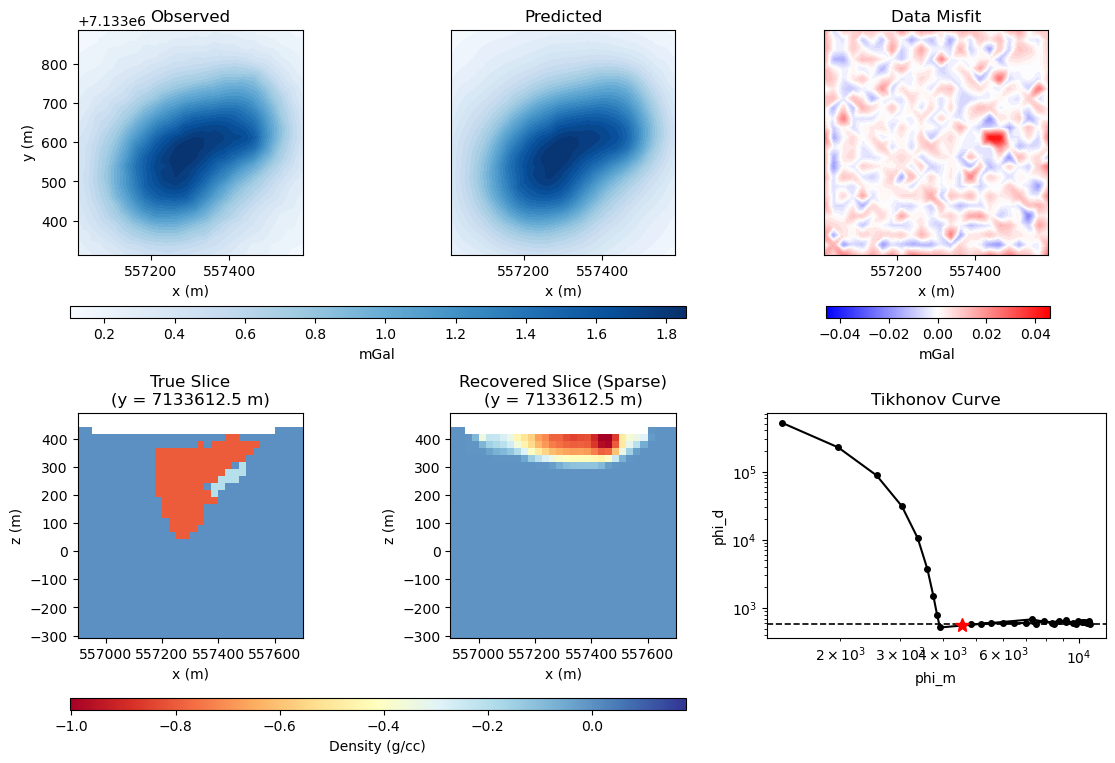

In [74]:
# Purpose: Plot the baseline IRLS data fit and recovered model slice.

# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
dpred_irls = inv_prob_irls.dpred
data_array_irls = np.c_[dobs, dpred_irls, dobs - dpred_irls]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

norm_data = mpl.colors.Normalize(
    vmin=np.min(data_array_irls[:, :2]),
    vmax=np.max(data_array_irls[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(data_array_irls[:, 2])),
    vmax=np.max(np.abs(data_array_irls[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_irls[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_irls[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_irls[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_tikhonov = fig.add_subplot(gs[1, 2])

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Fix model color scale across all inversion cases when available
shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_reweighted_l2_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_IRLS_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (Sparse)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

fig.subplots_adjust(bottom=0.12)
# Small model colorbar (below lower-row panels 1 and 2)
cax_model = fig.add_axes([0.16, 0.03, 0.44, 0.015])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="horizontal")
cbar_model.set_label("Density (g/cc)")

plot_tikhonov_curve(save_output_irls, "Tikhonov Curve", ax=ax_tikhonov)

plt.show()

## d. IRLS Norm Comparison

In [25]:
# Purpose: Convert geology classes into a true density model so all inversion results can be compared in density units.

# True density model from geology classes
rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2

# active-only version if needed
rho_true_active = rho_true[active_cells]

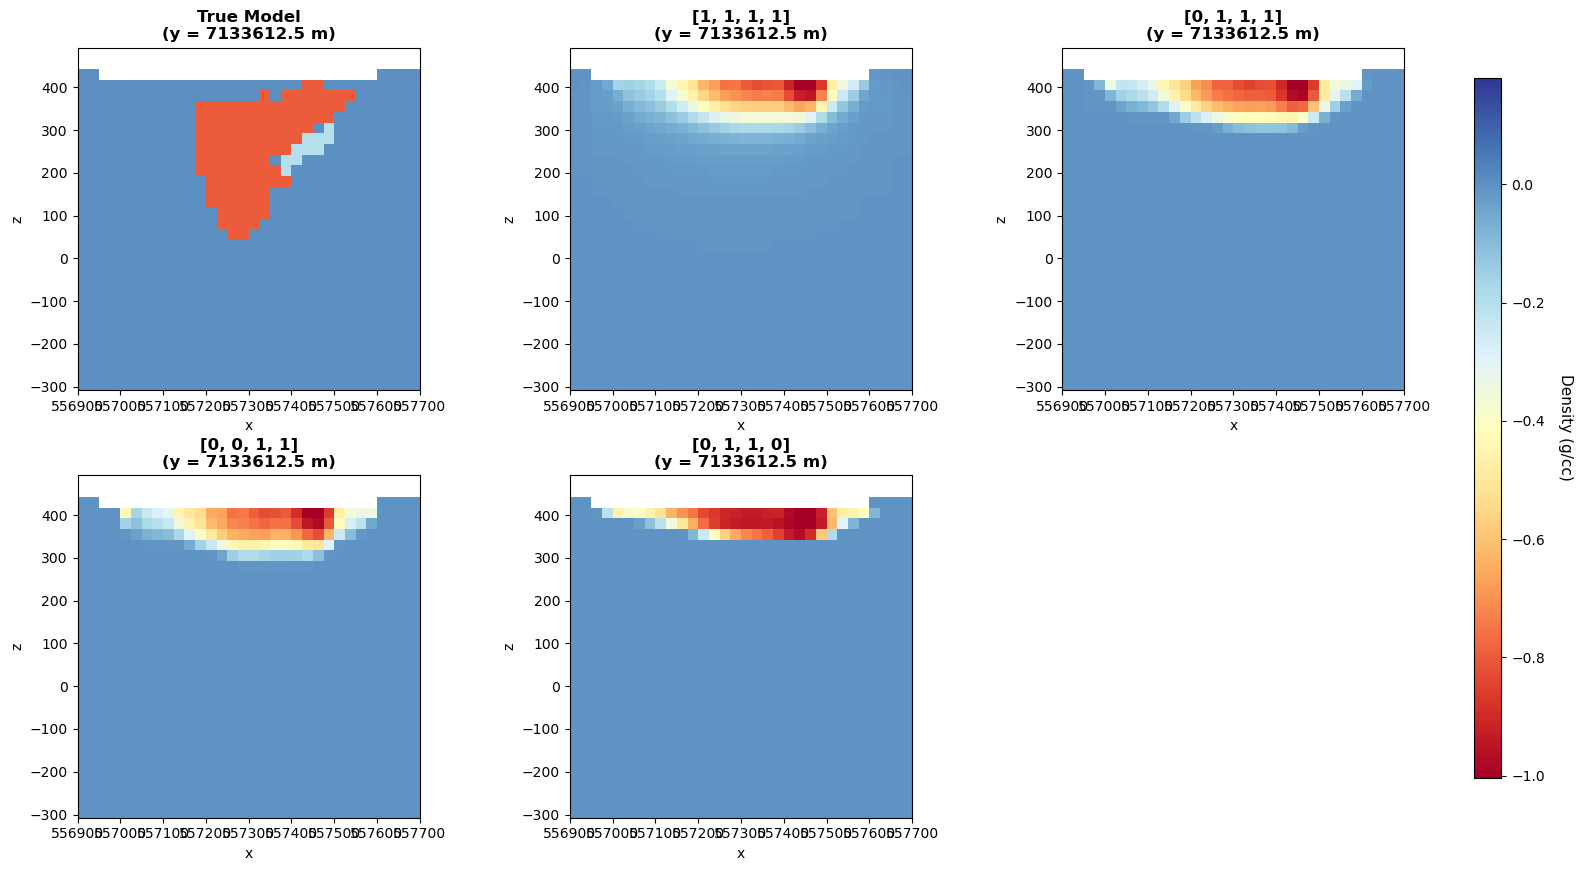

In [26]:
# Purpose: Compare multiple IRLS norm combinations on the same slice using a shared color scale.

# Compare four IRLS norm combinations on the same Y-slice with a shared colorbar
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.ravel()

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

case_models = [(case["label"], case["model"]) for case in irls_norm_results]
all_case_models = np.concatenate([rho_true_active] + [model for _, model in case_models])

models = [("True Model", rho_true_active)] + case_models

for i, (title, model_data) in enumerate(models):
    mesh.plot_slice(
        plotting_Map * model_data,
        normal="Y",
        ax=ax[i],
        ind=y_idx,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
    )
    ax[i].set_title(f"{title}\n(y = {y_val:.1f} m)", fontsize=12, fontweight="bold")
    ax[i].set_aspect(1)

ax[5].axis("off")

fig.subplots_adjust(right=0.90, wspace=0.20, hspace=0.25)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax, norm=norm_model, orientation="vertical", cmap=mpl.cm.RdYlBu
)
cbar.set_label("Density (g/cc)", rotation=270, labelpad=20, fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.show()

## e. Depth-Weighted IRLS

In [27]:
# Purpose: Compute depth weights and build the depth-weighted IRLS inversion setup.

# Depth weights for gravity
depth_weights = utils.depth_weighting(
    mesh,
    receiver_locations,
    active_cells=active_cells,
    exponent=2,
)

# Regularization for depth-weighted IRLS
reg_irls_depth = regularization.Sparse(
    mesh,
    active_cells=active_cells,
    alpha_s=dh**-2,
    alpha_x=1.0,
    alpha_y=1.0,
    alpha_z=1.0,
    reference_model=reference_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

reg_irls_depth.set_weights(depth_weights=depth_weights)

# Data misfit for depth-weighted IRLS (use original data_grav)
dmis_irls_depth = data_misfit.L2DataMisfit(data=data_grav, simulation=simulation_grav)

# Optimization for depth-weighted IRLS
opt_irls_depth = optimization.ProjectedGNCG(
    maxIter=100, lower=-1.0, upper=1.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

# Directives for IRLS
starting_beta_irls_depth = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls_depth = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls_depth = directives.UpdateIRLS(
    cooling_factor=2,
    cooling_rate=1,
    chifact_start=1.0,
    f_min_change=1e-4,
    max_irls_iterations=25,
)
save_output_irls_depth = directives.SaveOutputEveryIteration(save_txt=False)

directives_list_irls_depth = [
    update_irls_depth,
    starting_beta_irls_depth,
    update_jacobi_irls_depth,
    save_output_irls_depth,
]

Define and Run the Inversion

In [28]:
# Purpose: Assemble and run the depth-weighted IRLS inversion.

# Inverse problem for depth-weighted IRLS
inv_prob_irls_depth = inverse_problem.BaseInvProblem(dmis_irls_depth, reg_irls_depth, opt_irls_depth)
inv_irls_depth = inversion.BaseInversion(inv_prob_irls_depth, directives_list_irls_depth)

recovered_depth_model = inv_irls_depth.run(starting_model)


Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  7.39e+03  4.35e+06  6.73e-08  4.35e+06                         0           inf          inf                
   1  7.39e+03  9.24e+05  1.21e+02  1.82e+06    1.03e+02      0      6        9.31e-03     1.50e+04              
   2  3.70e+03  5.32e+05  1.96e+02  1.26e+06    1.02e+02      0      7        3.85e-03     1.01e+03              
   3  1.85e+03  2.85e+05  2.90e+02  8.20e+05    1.01e+02      0      6        9.33e-03     1.49e+03              
   4  9.24e+02  1.35e+05  4.03e+02  5.07e+05    1.01e+02      0      6        9.80e-03     9.12e+02              
   5  4.62e+02  5.58e+04  5.21e+02  2.97e+05    

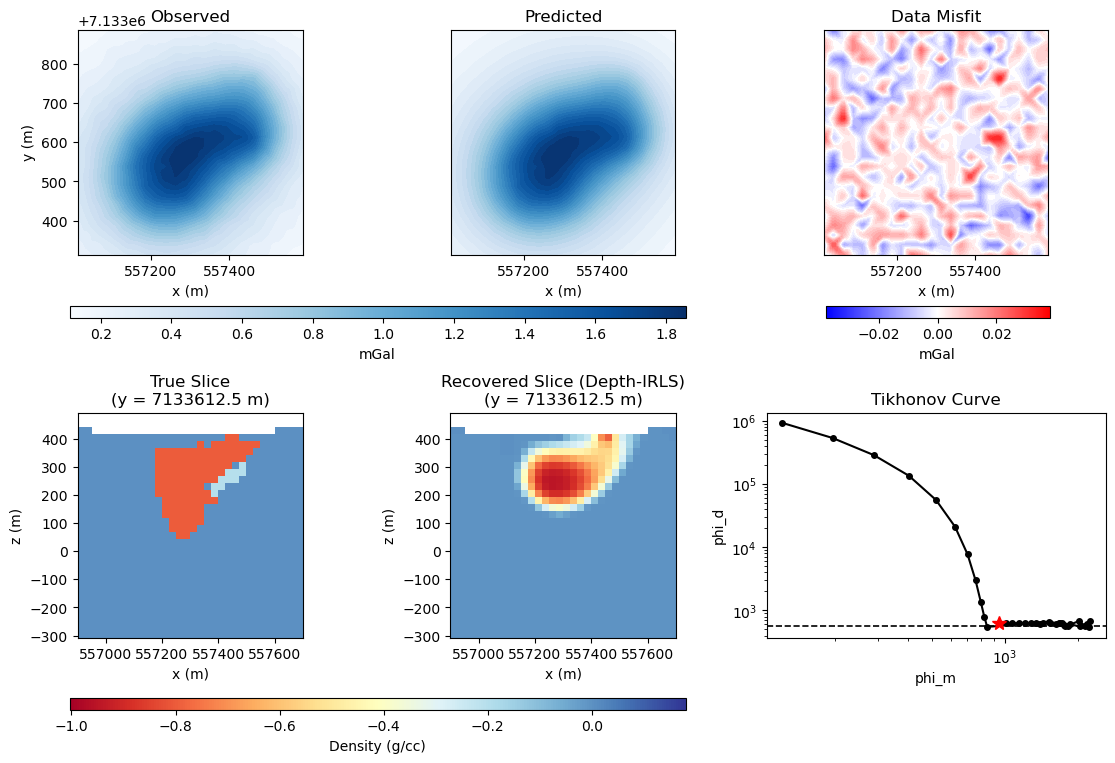

In [75]:
# Purpose: Plot the depth-weighted IRLS data fit and recovered model slice.

# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
dpred_irls_depth = inv_prob_irls_depth.dpred
data_array_depth = np.c_[dobs, dpred_irls_depth, dobs - dpred_irls_depth]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

norm_data = mpl.colors.Normalize(
    vmin=np.min(data_array_depth[:, :2]),
    vmax=np.max(data_array_depth[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(data_array_depth[:, 2])),
    vmax=np.max(np.abs(data_array_depth[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_depth[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_depth[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_depth[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_tikhonov = fig.add_subplot(gs[1, 2])

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Fix model color scale across all inversion cases when available
shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_reweighted_l2_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_depth_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (Depth-IRLS)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

fig.subplots_adjust(bottom=0.12)
# Small model colorbar (below lower-row panels 1 and 2)
cax_model = fig.add_axes([0.16, 0.03, 0.44, 0.015])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="horizontal")
cbar_model.set_label("Density (g/cc)")

plot_tikhonov_curve(save_output_irls_depth, "Tikhonov Curve", ax=ax_tikhonov)

plt.show()

## f. Depth-Weighted IRLS Norm Comparison

In [30]:
# Purpose: Re-run the depth-weighted IRLS inversion with multiple norm combinations for sensitivity analysis.

# Run multiple norm combinations for depth-weighted IRLS
def run_depth_irls_norm_case(case_label, case_norms):
    reg_case = regularization.Sparse(
        mesh,
        active_cells=active_cells,
        alpha_s=dh**-2,
        alpha_x=1.0,
        alpha_y=1.0,
        alpha_z=1.0,
        reference_model=reference_model,
        reference_model_in_smooth=False,
        norms=case_norms,
    )
    reg_case.set_weights(depth_weights=depth_weights)

    opt_case = optimization.ProjectedGNCG(
        maxIter=100, lower=-1.0, upper=1.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
    )

    starting_beta_case = directives.BetaEstimate_ByEig(beta0_ratio=10)
    update_jacobi_case = directives.UpdatePreconditioner(update_every_iteration=True)
    update_irls_case = directives.UpdateIRLS(
        cooling_factor=2,
        cooling_rate=1,
        chifact_start=1.0,
        f_min_change=1e-4,
        max_irls_iterations=25,
    )

    directives_list_case = [
        update_irls_case,
        starting_beta_case,
        update_jacobi_case,
    ]

    inv_prob_case = inverse_problem.BaseInvProblem(dmis_irls_depth, reg_case, opt_case)
    inv_case = inversion.BaseInversion(inv_prob_case, directives_list_case)
    recovered_case = inv_case.run(starting_model)

    return {
        "label": case_label,
        "norms": case_norms,
        "inv_prob": inv_prob_case,
        "model": recovered_case,
    }

depth_irls_norm_results = []
for case_label, case_norms in irls_norm_cases:
    print(f"Running depth-weighted IRLS norms {case_label}")
    depth_irls_norm_results.append(run_depth_irls_norm_case(case_label, case_norms))

Running depth-weighted IRLS norms [1, 1, 1, 1]

Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  7.52e+03  4.35e+06  6.73e-08  4.35e+06                         0           inf          inf                
   1  7.52e+03  9.36e+05  1.20e+02  1.84e+06    1.03e+02      0      6        9.39e-03     1.51e+04              
   2  3.76e+03  5.39e+05  1.94e+02  1.27e+06    1.02e+02      0      7        3.86e-03     1.02e+03              
   3  1.88e+03  2.89e+05  2.87e+02  8.29e+05    1.01e+02      0      6        9.27e-03     1.50e+03              
   4  9.40e+02  1.37e+05  4.00e+02  5.13e+05    1.01e+02      0      6        9.81e-03     9.25e+02              
 

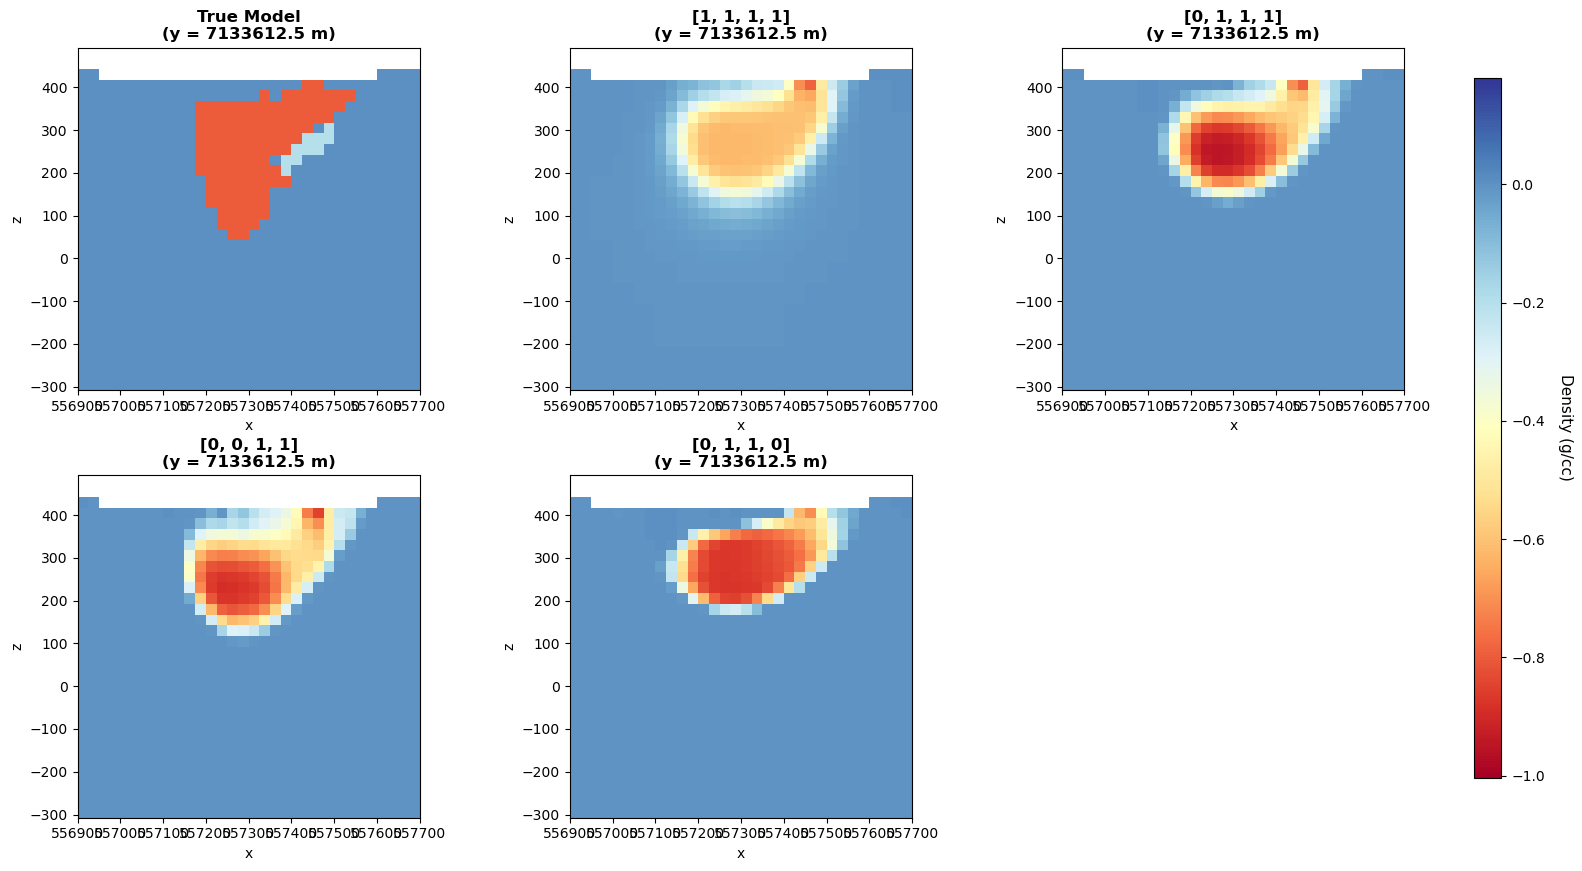

In [31]:
# Purpose: Compare the depth-weighted IRLS norm combinations on a common slice and color scale.

# Compare depth-weighted IRLS norm combinations on the same Y-slice with a shared colorbar
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.ravel()

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

case_models = [(case["label"], case["model"]) for case in depth_irls_norm_results]
all_case_models = np.concatenate([rho_true_active] + [model for _, model in case_models])

models = [("True Model", rho_true_active)] + case_models

for i, (title, model_data) in enumerate(models):
    mesh.plot_slice(
        plotting_Map * model_data,
        normal="Y",
        ax=ax[i],
        ind=y_idx,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
    )
    ax[i].set_title(f"{title}\n(y = {y_val:.1f} m)", fontsize=12, fontweight="bold")
    ax[i].set_aspect(1)

ax[5].axis("off")

fig.subplots_adjust(right=0.90, wspace=0.20, hspace=0.25)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax, norm=norm_model, orientation="vertical", cmap=mpl.cm.RdYlBu
)
cbar.set_label("Density (g/cc)", rotation=270, labelpad=20, fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.show()

## g. Sensitivity-Weighted IRLS

In [32]:
# Purpose: Build the sensitivity-weighted IRLS inversion by adding sensitivity-based weighting to the sparse formulation.

# =========================
# Sensitivity-weighted IRLS inversion
# =========================

# Data misfit
dmis_irls_sens = data_misfit.L2DataMisfit(
    data=data_grav,
    simulation=simulation_grav,
)

# Sparse regularization
reg_irls_sens = regularization.Sparse(
    mesh,
    active_cells=active_cells,
    alpha_s=dh**-2,
    alpha_x=1.0,
    alpha_y=1.0,
    alpha_z=1.0,
    reference_model=reference_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

# Optimization
opt_irls_sens = optimization.ProjectedGNCG(
    maxIter=100,
    lower=-1.0,
    upper=1.0,
    maxIterLS=20,
    cg_maxiter=10,
    cg_rtol=1e-2,
)

# Directives for IRLS
sensitivity_weights_irls_sens = directives.UpdateSensitivityWeights(every_iteration=False)
starting_beta_irls_sens = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls_sens = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls_sens = directives.UpdateIRLS(
    cooling_factor=2,
    cooling_rate=1,
    chifact_start=1.0,
    f_min_change=1e-4,
    max_irls_iterations=25,
)
save_output_irls_sens = directives.SaveOutputEveryIteration(save_txt=False)

directives_list_irls_sens = [
    sensitivity_weights_irls_sens,
    update_irls_sens,
    starting_beta_irls_sens,
    update_jacobi_irls_sens,
    save_output_irls_sens,
]

In [33]:
# Purpose: Assemble and run the sensitivity-weighted IRLS inversion.

# Inverse problem
inv_prob_irls_sens = inverse_problem.BaseInvProblem(dmis_irls_sens, reg_irls_sens, opt_irls_sens)
inv_irls_sens = inversion.BaseInversion(inv_prob_irls_sens, directives_list_irls_sens)

# Run inversion
recovered_irls_sens_model = inv_irls_sens.run(starting_model)


Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.67e+04  4.35e+06  2.87e-08  4.35e+06                         0           inf          inf                
   1  1.67e+04  1.08e+06  5.15e+01  1.94e+06    1.03e+02      0      7        4.77e-03     7.69e+03              
   2  8.37e+03  6.85e+05  8.47e+01  1.39e+06    1.02e+02      0      7        4.64e-03     1.27e+03              
   3  4.19e+03  4.10e+05  1.31e+02  9.59e+05    1.01e+02      0      7        4.36e-03     7.51e+02              
   4  2.09e+03  2.16e+05  1.97e+02  6.27e+05    1.00e+02      0      7        4.92e-03     5.23e+02              
   5  1.05e+03  9.81e+04  2.75e+02  3.86e+05    

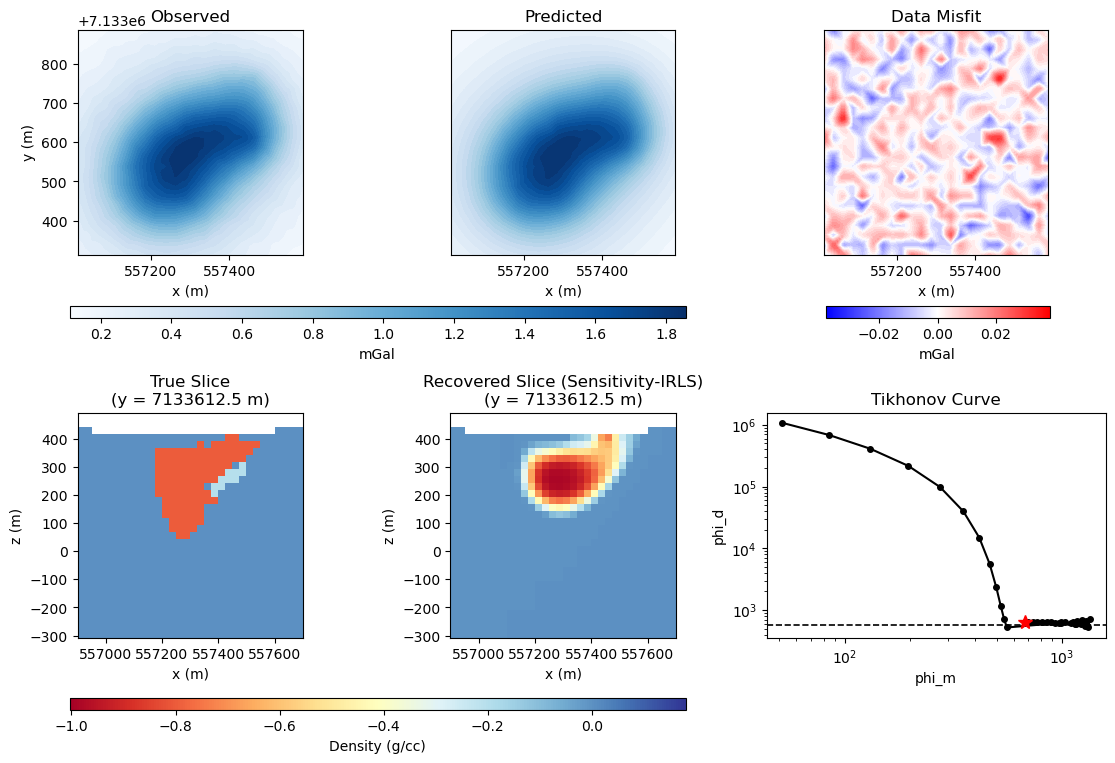

In [76]:
# Purpose: Plot the sensitivity-weighted IRLS data fit and recovered model slice.

# Observed / Predicted / Misfit + True/Recovered slices (clean 2x3 layout)
dpred_irls_sens = inv_prob_irls_sens.dpred
data_array_sens = np.c_[dobs, dpred_irls_sens, dobs - dpred_irls_sens]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.7, wspace=0.10)

# Top row (keep three data panels)
ax_data = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_title = ["Observed", "Predicted", "Data Misfit"]

norm_data = mpl.colors.Normalize(
    vmin=np.min(data_array_sens[:, :2]),
    vmax=np.max(data_array_sens[:, :2]),
)
norm_misfit = mpl.colors.Normalize(
    vmin=-np.max(np.abs(data_array_sens[:, 2])),
    vmax=np.max(np.abs(data_array_sens[:, 2])),
)

plot2Ddata(
    receiver_locations,
    data_array_sens[:, 0],
    ax=ax_data[0],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[0].set_title(plot_title[0])
ax_data[0].set_xlabel("x (m)")
ax_data[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations,
    data_array_sens[:, 1],
    ax=ax_data[1],
    ncontour=30,
    contourOpts={"cmap": "Blues", "norm": norm_data},
)
ax_data[1].set_title(plot_title[1])
ax_data[1].set_xlabel("x (m)")
ax_data[1].set_yticks([])

plot2Ddata(
    receiver_locations,
    data_array_sens[:, 2],
    ax=ax_data[2],
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm_misfit},
)
ax_data[2].set_title(plot_title[2])
ax_data[2].set_xlabel("x (m)")
ax_data[2].set_yticks([])

# Shared colorbar for observed/predicted data
cax_data = fig.add_axes([0.16, 0.52, 0.44, 0.015])
sm_data = mpl.cm.ScalarMappable(norm=norm_data, cmap=mpl.cm.Blues)
cbar_data = fig.colorbar(sm_data, cax=cax_data, orientation="horizontal")
cbar_data.set_label("mGal")

# Dedicated colorbar for data misfit (third panel)
cax_misfit = fig.add_axes([0.7, 0.52, 0.16, 0.015])
sm_misfit = mpl.cm.ScalarMappable(norm=norm_misfit, cmap=mpl.cm.bwr)
cbar_misfit = fig.colorbar(sm_misfit, cax=cax_misfit, orientation="horizontal")
cbar_misfit.set_label("mGal")

# Bottom row: true and recovered model slices
ax_true = fig.add_subplot(gs[1, 0])
ax_rec = fig.add_subplot(gs[1, 1])
ax_tikhonov = fig.add_subplot(gs[1, 2])

rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Fix model color scale across all inversion cases when available
shared_models = [rho_true_active]
for name in [
    "recovered_model",
    "recovered_IRLS_model",
    "recovered_depth_model",
    "recovered_irls_sens_model",
    "recovered_reweighted_l2_model",
]:
    if name in globals():
        shared_models.append(globals()[name])
shared_model_values = np.concatenate(shared_models)
norm_model = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

mesh.plot_slice(
    plotting_Map * rho_true_active,
    normal="Y",
    ind=y_idx,
    ax=ax_true,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_true.set_title(f"True Slice\n(y = {y_val:.1f} m)")
ax_true.set_xlabel("x (m)")
ax_true.set_ylabel("z (m)")
ax_true.set_aspect(1)

mesh.plot_slice(
    plotting_Map * recovered_irls_sens_model,
    normal="Y",
    ind=y_idx,
    ax=ax_rec,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
)
ax_rec.set_title(f"Recovered Slice (Sensitivity-IRLS)\n(y = {y_val:.1f} m)")
ax_rec.set_xlabel("x (m)")
ax_rec.set_ylabel("z (m)")
ax_rec.set_aspect(1)

fig.subplots_adjust(bottom=0.12)
# Small model colorbar (below lower-row panels 1 and 2)
cax_model = fig.add_axes([0.16, 0.03, 0.44, 0.015])
sm_model = mpl.cm.ScalarMappable(norm=norm_model, cmap=mpl.cm.RdYlBu)
cbar_model = fig.colorbar(sm_model, cax=cax_model, orientation="horizontal")
cbar_model.set_label("Density (g/cc)")

plot_tikhonov_curve(save_output_irls_sens, "Tikhonov Curve", ax=ax_tikhonov)

plt.show()

## h. Sensitivity-Weighted IRLS Norm Comparison

In [35]:
# Purpose: Re-run the sensitivity-weighted IRLS inversion with multiple norm combinations for comparison.

# Run multiple norm combinations for sensitivity-weighted IRLS
def run_sensitivity_irls_norm_case(case_label, case_norms):
    reg_case = regularization.Sparse(
        mesh,
        active_cells=active_cells,
        alpha_s=dh**-2,
        alpha_x=1.0,
        alpha_y=1.0,
        alpha_z=1.0,
        reference_model=reference_model,
        reference_model_in_smooth=False,
        norms=case_norms,
    )

    opt_case = optimization.ProjectedGNCG(
        maxIter=100, lower=-1.0, upper=1.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
    )

    sensitivity_weights_case = directives.UpdateSensitivityWeights(every_iteration=False)
    starting_beta_case = directives.BetaEstimate_ByEig(beta0_ratio=10)
    update_jacobi_case = directives.UpdatePreconditioner(update_every_iteration=True)
    update_irls_case = directives.UpdateIRLS(
        cooling_factor=2,
        cooling_rate=1,
        chifact_start=1.0,
        f_min_change=1e-4,
        max_irls_iterations=25,
    )

    directives_list_case = [
        sensitivity_weights_case,
        update_irls_case,
        starting_beta_case,
        update_jacobi_case,
    ]

    inv_prob_case = inverse_problem.BaseInvProblem(dmis_irls_sens, reg_case, opt_case)
    inv_case = inversion.BaseInversion(inv_prob_case, directives_list_case)
    recovered_case = inv_case.run(starting_model)

    return {
        "label": case_label,
        "norms": case_norms,
        "inv_prob": inv_prob_case,
        "model": recovered_case,
    }

sens_irls_norm_results = []
for case_label, case_norms in irls_norm_cases:
    print(f"Running sensitivity-weighted IRLS norms {case_label}")
    sens_irls_norm_results.append(run_sensitivity_irls_norm_case(case_label, case_norms))

Running sensitivity-weighted IRLS norms [1, 1, 1, 1]

Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.36e+04  4.35e+06  2.87e-08  4.35e+06                         0           inf          inf                
   1  1.36e+04  9.45e+05  6.04e+01  1.77e+06    1.03e+02      0      6        9.24e-03     1.49e+04              
   2  6.79e+03  5.92e+05  9.71e+01  1.25e+06    1.02e+02      0      7        3.94e-03     9.43e+02              
   3  3.39e+03  3.43e+05  1.49e+02  8.49e+05    1.01e+02      0      7        4.63e-03     6.90e+02              
   4  1.70e+03  1.73e+05  2.19e+02  5.45e+05    1.00e+02      0      7        5.95e-03     5.46e+02          

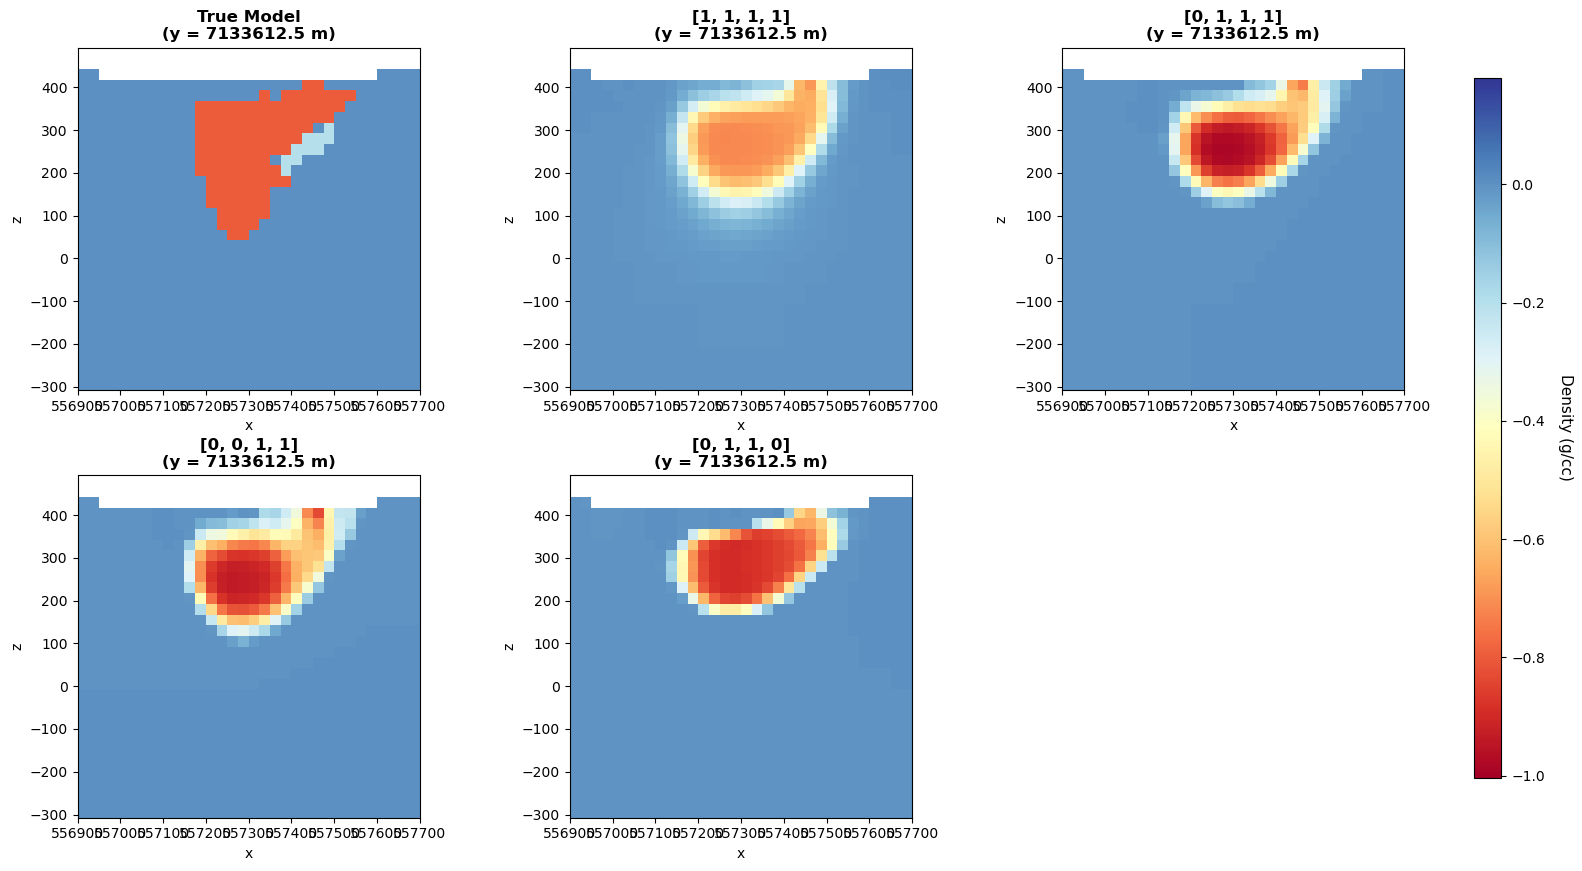

In [36]:
# Purpose: Compare the sensitivity-weighted IRLS norm combinations on a common slice and color scale.

# Compare sensitivity-weighted IRLS norm combinations on the same Y-slice with a shared colorbar
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.ravel()

y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

case_models = [(case["label"], case["model"]) for case in sens_irls_norm_results]
all_case_models = np.concatenate([rho_true_active] + [model for _, model in case_models])

models = [("True Model", rho_true_active)] + case_models

for i, (title, model_data) in enumerate(models):
    mesh.plot_slice(
        plotting_Map * model_data,
        normal="Y",
        ax=ax[i],
        ind=y_idx,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm_model},
    )
    ax[i].set_title(f"{title}\n(y = {y_val:.1f} m)", fontsize=12, fontweight="bold")
    ax[i].set_aspect(1)

ax[5].axis("off")

fig.subplots_adjust(right=0.90, wspace=0.20, hspace=0.25)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax, norm=norm_model, orientation="vertical", cmap=mpl.cm.RdYlBu
)
cbar.set_label("Density (g/cc)", rotation=270, labelpad=20, fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.show()

In [37]:
# Purpose: Build a shared density normalization across all inversion cases so the final comparison uses consistent colors.

# Shared density normalization across all inversion cases
rho_true = np.zeros_like(true_geology, dtype=float)
rho_true[true_geology == 0] = 0.0
rho_true[true_geology == 1] = -0.8
rho_true[true_geology == 2] = -0.2
rho_true_active = rho_true[active_cells]

shared_model_list = [
    rho_true_active,
    recovered_model,
    recovered_reweighted_l2_model,
    recovered_IRLS_model,
    recovered_depth_model,
    recovered_irls_sens_model,
]

if "irls_norm_results" in globals():
    shared_model_list.extend([case["model"] for case in irls_norm_results])
if "depth_irls_norm_results" in globals():
    shared_model_list.extend([case["model"] for case in depth_irls_norm_results])
if "sens_irls_norm_results" in globals():
    shared_model_list.extend([case["model"] for case in sens_irls_norm_results])

shared_model_values = np.concatenate(shared_model_list)

norm_model_shared = mpl.colors.Normalize(
    vmin=np.min(shared_model_values),
    vmax=np.max(shared_model_values),
)

## Final Comparison: All Cases (Same Slice, Shared Colorbar)

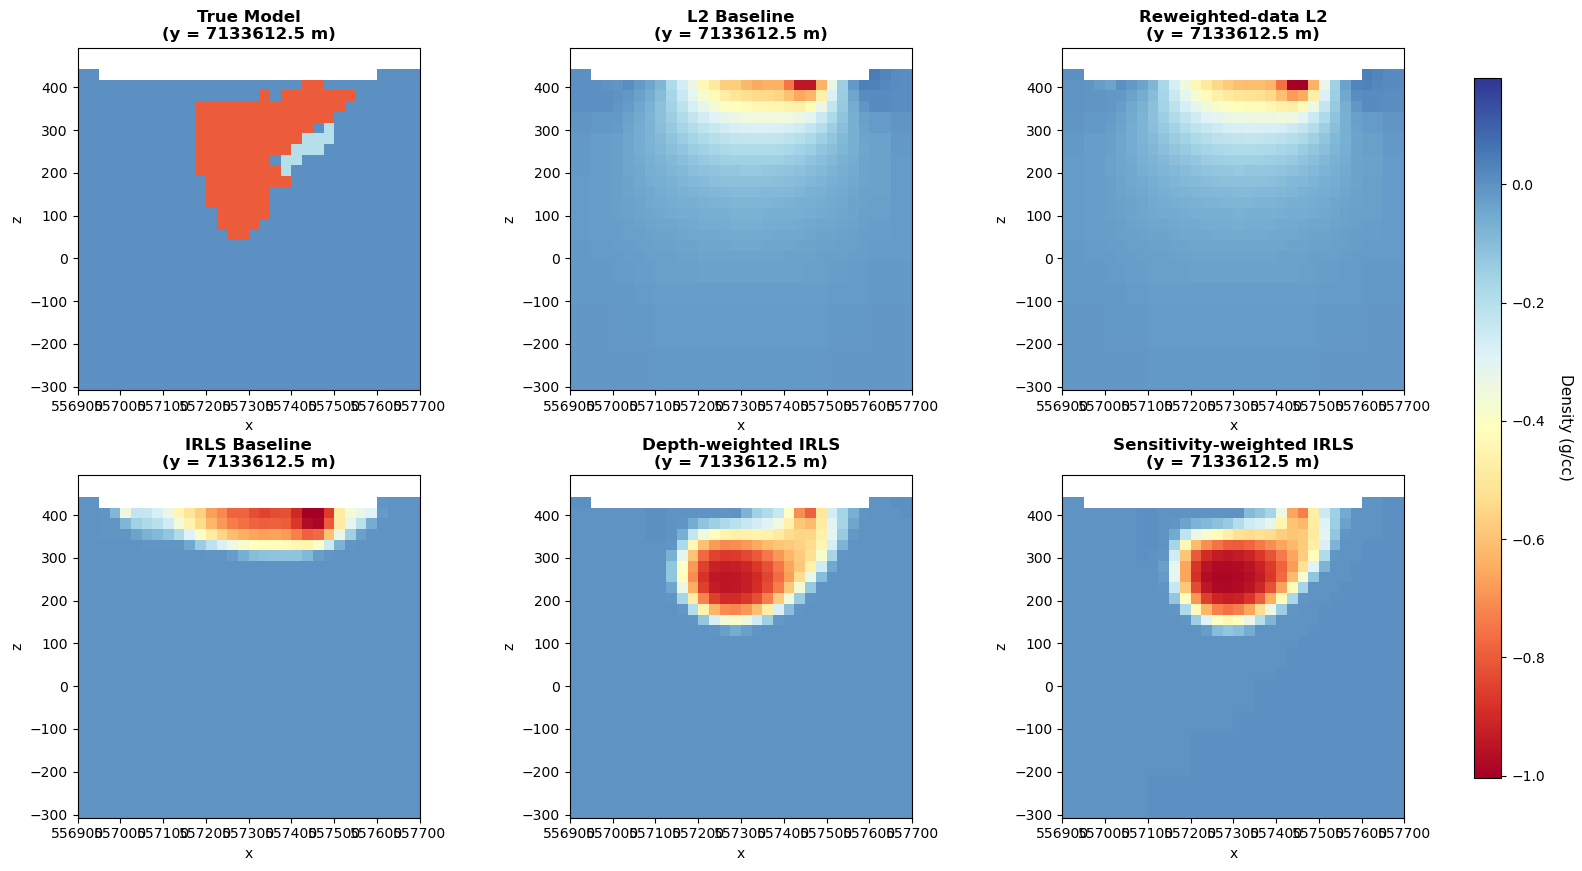

In [77]:
# Purpose: Plot the true model and all main inversion results together on the same slice for a final side-by-side comparison.

# Plot True + all inversion cases on the same Y-slice with a shared colorbar
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.ravel()

# Define the slice index
y_idx = int(mesh.shape_cells[1] / 2)
y_val = mesh.cell_centers_y[y_idx]

# Assemble all models for comparison
models = [
    ("True Model", rho_true_active),
    ("L2 Baseline", recovered_model),
    ("Reweighted-data L2", recovered_reweighted_l2_model),
    ("IRLS Baseline", recovered_IRLS_model),
    ("Depth-weighted IRLS", recovered_depth_model),
    ("Sensitivity-weighted IRLS", recovered_irls_sens_model),
]

# Use the same density normalization as the individual case plots
norm = norm_model_shared

for i, (title, model_data) in enumerate(models):
    mesh.plot_slice(
        plotting_Map * model_data,
        normal="Y",
        ax=ax[i],
        ind=y_idx,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.RdYlBu, "norm": norm},
    )
    ax[i].set_title(f"{title}\n(y = {y_val:.1f} m)", fontsize=12, fontweight="bold")
    ax[i].set_aspect(1)

# Shared colorbar
fig.subplots_adjust(right=0.90, wspace=0.20, hspace=0.25)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu
)
cbar.set_label("Density (g/cc)", rotation=270, labelpad=20, fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.show()

In [39]:
# Purpose: Placeholder cell for optional notes, exports, or future extensions to the workflow.
